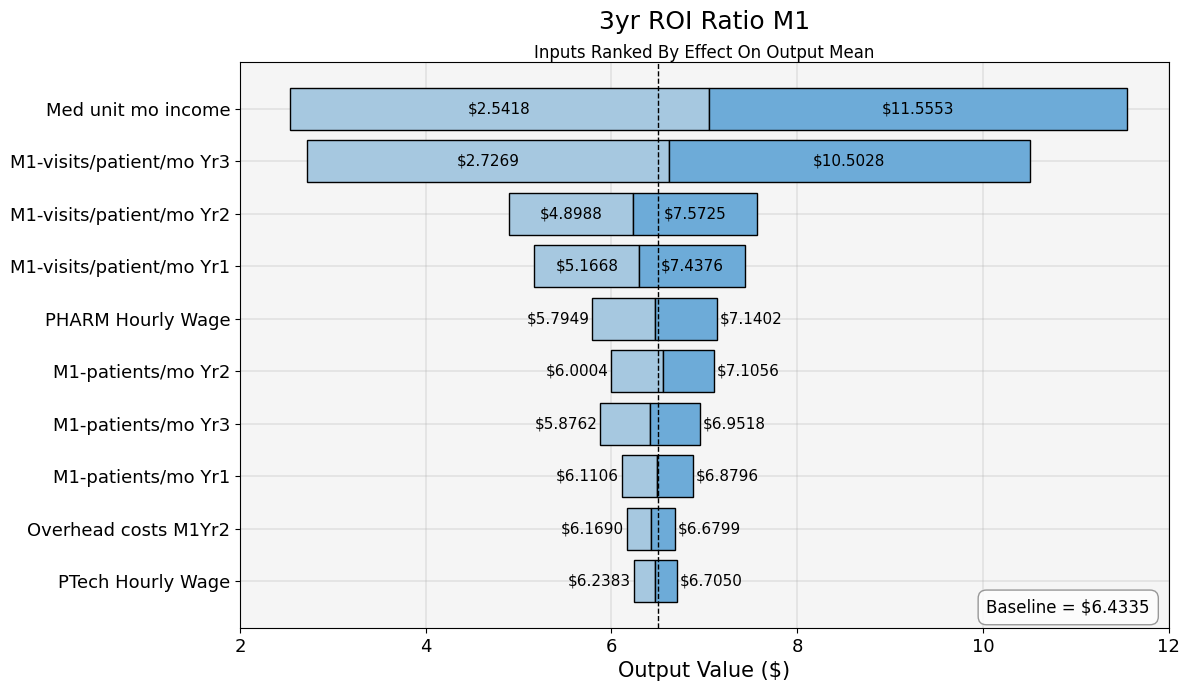

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Load your CSV
df = pd.read_csv(r"C:\Users\murra\Downloads\M1_ROI-Ratio_Tornado_2025-07-19(Sheet1).csv")

# Rename first column if needed
df.rename(columns={'Unnamed: 0': 'Parameter'}, inplace=True)

# Convert data columns to numeric
df['Y'] = pd.to_numeric(df['Y'], errors='coerce')
df['Y2'] = pd.to_numeric(df['Y2'], errors='coerce')

# Clean L and L2 columns by stripping '$' and spaces, then convert to float
df['L'] = df['L'].astype(str).str.replace('$', '').str.strip()
df['L2'] = df['L2'].astype(str).str.replace('$', '').str.strip()

df['L'] = pd.to_numeric(df['L'], errors='coerce')
df['L2'] = pd.to_numeric(df['L2'], errors='coerce')

# Midpoint and absolute difference
df['Mid'] = (df['Y'] + df['Y2']) / 2
df['Diff'] = abs(df['Y2'] - df['Y'])

# Sort for tornado layout
df = df.sort_values('Diff', ascending=True)

# Set style
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'axes.facecolor': '#f5f5f5'
})

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))
label_fontsize = 11

# Threshold and padding settings
threshold = 0.7  # Minimum bar width to place label inside bar
label_pad = 0.03  # Padding for labels outside bars

# Plot limits for nudging labels inside
xlim_left, xlim_right = 2, 12
ax.set_xlim(xlim_left, xlim_right)

for idx, row in df.iterrows():
    param = row['Parameter']
    y1 = row['Y']
    y2 = row['Y2']
    mid = (y1 + y2) / 2
    start = min(y1, y2)
    end = max(y1, y2)

    label_L = f"${row['Y']:.4f}"
    label_L2 = f"${row['Y2']:.4f}"

    left_width = mid - start
    right_width = end - mid

    # Plot bars
    ax.barh(param, left_width, left=start, color="#a6c8e0", edgecolor='black')
    ax.barh(param, right_width, left=mid, color="#6dabd8", edgecolor='black')

    # Left label position and alignment
    if left_width > threshold:
        x_pos_left = start + left_width / 2
        ha_left = 'center'
    else:
        x_pos_left = start - label_pad
        # Nudge inside if outside left limit
        if x_pos_left < xlim_left:
            x_pos_left = start + label_pad
            ha_left = 'left'
        else:
            ha_left = 'right'

    ax.text(x_pos_left, param, label_L, ha=ha_left, va='center', fontsize=label_fontsize)

    # Right label position and alignment
    if right_width > threshold:
        x_pos_right = mid + right_width / 2
        ha_right = 'center'
    else:
        x_pos_right = end + label_pad
        # Nudge inside if outside right limit
        if x_pos_right > xlim_right:
            x_pos_right = end - label_pad
            ha_right = 'right'
        else:
            ha_right = 'left'

    ax.text(x_pos_right, param, label_L2, ha=ha_right, va='center', fontsize=label_fontsize)

# Add baseline line
baseline = df['Mid'].mean()
ax.axvline(x=baseline, color='black', linestyle='--', linewidth=1)

# Title and labels
ax.set_xlabel('Output Value ($)')
ax.set_title("")
ax.text(0.5, 1.05, "3yr ROI Ratio M1", fontsize=18,
        ha='center', va='bottom', transform=ax.transAxes)
ax.text(0.5, 1.00, "Inputs Ranked By Effect On Output Mean", fontsize=12,
        ha='center', va='bottom', transform=ax.transAxes)
ax.text(
    0.98, 0.02,
    f'Baseline = $6.4335',
    fontsize=12,
    ha='right', va='bottom',
    transform=ax.transAxes,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.8)
)

# Grid
ax.grid(True, linewidth=0.35, alpha=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()